<a href="https://colab.research.google.com/github/saiKelkar/Product_Oriented_Scan-to-CAD_Dimensional_Inspection_System/blob/main/scan_to_cad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install open3d

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import Open3D and NumPy
import open3d as o3d
import numpy as np

In [4]:
CAD_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/Lbracket.stl"
print(CAD_PATH)

/content/drive/MyDrive/Scan-to-CAD_System/Lbracket.stl


In [5]:
# Load the L-bracket (nominal STL)
mesh = o3d.io.read_triangle_mesh(CAD_PATH)

print(mesh)

TriangleMesh with 2128 points and 1140 triangles.


In [7]:
# Inspect Mesh
print("Vertices:", len(mesh.vertices))
print("Triangles:", len(mesh.triangles))
print("Is empty:", mesh.is_empty())

Vertices: 2128
Triangles: 1140
Is empty: False


In [8]:
# Find the mesh dimensions (bounding box)
bbox = mesh.get_axis_aligned_bounding_box()

min_bound = bbox.get_min_bound()
max_bound = bbox.get_max_bound()
dimensions = bbox.get_extent()

print("Minimum coordinates:", min_bound)
print("Maximum coordinates:", max_bound)

print("\nBounding-box dimensions:")
print("X:", dimensions[0])
print("Y:", dimensions[1])
print("Z:", dimensions[2])

Minimum coordinates: [-1. -1.  0.]
Maximum coordinates: [14.  48.5 49.5]

Bounding-box dimensions:
X: 15.0
Y: 49.5
Z: 49.5


In [9]:
# Visualize nominal CAD
import plotly.graph_objects as go

vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=triangles[:, 0],
            j=triangles[:, 1],
            k=triangles[:, 2],
            opacity=0.8
        )
    ]
)

fig.update_layout(
    title="Nominal CAD - L-Bracket",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=800,
    height=650
)

fig.show()

### Nominal CAD Coordinate System
- X: bracket width
- Y: horizontal flange direction
- Z: vertical flange direction

Overall bounding dimensions:
- X: 15.0 mm
- Y: 49.5 mm
- Z: 49.5 mm

In [10]:
vertices = np.asarray(mesh.vertices)

print("Shape:", vertices.shape)
print("\nFirst 10 vertices:")
print(vertices[:10])

Shape: (2128, 3)

First 10 vertices:
[[14.          3.5         0.77273029]
 [14.         47.72726822  0.77273029]
 [14.         47.72726822  3.72726965]
 [14.          2.72726965  3.72726965]
 [ 5.22037363 37.57077026  0.        ]
 [ 4.85345554 37.37464905  0.        ]
 [-0.46701497 47.48698425  0.        ]
 [13.44318295 47.48727036  0.        ]
 [ 7.93122196 37.46218872  0.        ]
 [ 7.72808933 37.57077026  0.        ]]


In [12]:
# Computing normals
mesh.compute_vertex_normals()

print(mesh)

TriangleMesh with 2128 points and 1140 triangles.


In [13]:
pcd_perfect = mesh.sample_points_poisson_disk(
    number_of_points=10000
)

print(pcd_perfect)

PointCloud with 10000 points.


In [14]:
points = np.asarray(pcd_perfect.points)

print("Shape:", points.shape)
print("\nFirst 10 points:")
print(points[:10])

Shape: (10000, 3)

First 10 points:
[[10.18652997 -1.         26.48905673]
 [ 2.35648372 28.57834912  0.        ]
 [-1.          2.09325757 42.75057149]
 [14.          0.18426994 27.86692373]
 [ 1.51655456 23.88039046  4.5       ]
 [ 2.89757319 -1.         27.96992385]
 [ 9.05434742 36.14975622  0.22814413]
 [11.79429132  3.5        46.50572916]
 [14.          9.36933653  3.34293962]
 [ 5.67757184 32.18545884  1.1207589 ]]


In [15]:
points = np.asarray(pcd_perfect.points)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode="markers",
            marker=dict(
                size=2
            )
        )
    ]
)

fig.update_layout(
    title="Perfect Synthetic Scan - 10,000 Points",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data"
    ),
    width=800,
    height=650
)

fig.show()

In [16]:
# Saving the .ply file
OUTPUT_PATH = "/content/drive/MyDrive/Scan-to-CAD_System/perfect_scan.ply"

o3d.io.write_point_cloud(
    OUTPUT_PATH,
    pcd_perfect
)

print("Saved to:", OUTPUT_PATH)

Saved to: /content/drive/MyDrive/Scan-to-CAD_System/perfect_scan.ply


In [17]:
# Calculating bounding box of our point cloud
pcd_bbox = pcd_perfect.get_axis_aligned_bounding_box()

print("CAD dimensions:", mesh.get_axis_aligned_bounding_box().get_extent())
print("\nPoint cloud dimensions:", pcd_bbox.get_extent())

CAD dimensions: [15.  49.5 49.5]

Point cloud dimensions: [15.  49.5 49.5]


In [18]:
vertices = np.asarray(mesh.vertices)

x = vertices[:, 0]
y = vertices[:, 1]
z = vertices[:, 2]

print("X range:", x.min(), "to", x.max())
print("Y range:", y.min(), "to", y.max())
print("Z range:", z.min(), "to", z.max())

X range: -1.0 to 14.0
Y range: -1.0 to 48.5
Z range: 0.0 to 49.5


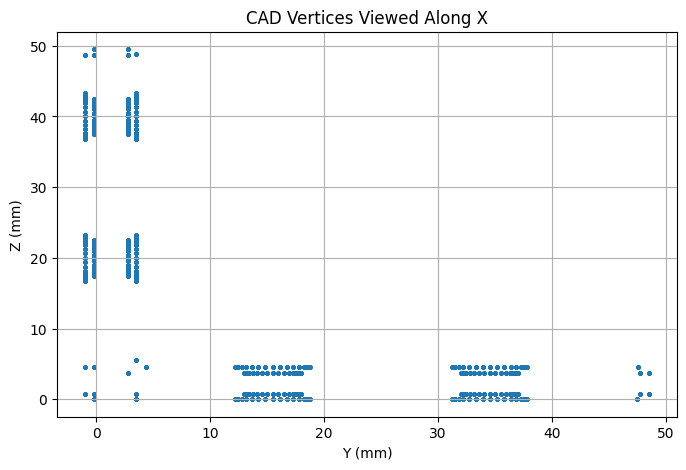

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y, z, s=5)

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("CAD Vertices Viewed Along X")
plt.grid(True)

plt.show()

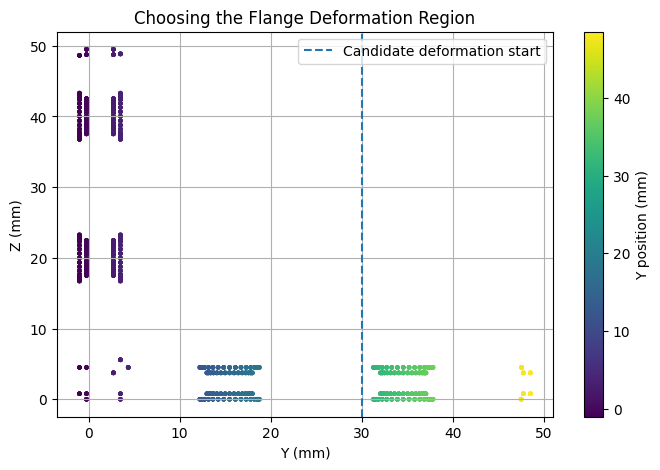

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y,
    z,
    s=5,
    c=y,
    cmap="viridis"
)

plt.axvline(
    x=30,
    linestyle="--",
    label="Candidate deformation start"
)

plt.xlabel("Y (mm)")
plt.ylabel("Z (mm)")
plt.title("Choosing the Flange Deformation Region")
plt.colorbar(label="Y position (mm)")
plt.legend()
plt.grid(True)

plt.show()